# 08 · Model Evaluation

[← Course home](../README.md)

**What you will learn**

- Cross-validation splitters (k-fold, stratified, repeated, group, time-series), what their folds look like,
  and how much a CV estimate itself varies
- `cross_validate` with several metrics at once
- The confusion matrix (from scratch and with `ConfusionMatrixDisplay`), precision, recall, F1, specificity
- The **accuracy paradox** on imbalanced data, and **threshold moving**
- Building a **ROC curve from scratch**, the probabilistic meaning of AUC, and why **precision–recall** curves
  are more informative under heavy imbalance
- Choosing a decision threshold from **misclassification costs**
- **Calibration**: reliability diagrams, Brier score, `CalibratedClassifierCV`
- Regression metrics and residual plots
- Comparing two models statistically with **paired** CV differences

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.datasets import load_breast_cancer, load_diabetes, make_classification
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import (ConfusionMatrixDisplay, PredictionErrorDisplay, accuracy_score,
                             average_precision_score, brier_score_loss, confusion_matrix, f1_score,
                             log_loss, make_scorer, mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, median_absolute_error, precision_recall_curve,
                             precision_score, r2_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GroupKFold, KFold, RepeatedStratifiedKFold, StratifiedKFold,
                                     TimeSeriesSplit, TunedThresholdClassifierCV, cross_val_score,
                                     cross_validate, train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from mlaz import PALETTE, savefig, set_style

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.precision", 4)

## 1 · Cross-validation splitters

A single train/test split gives one noisy number. **k-fold cross-validation** splits the data into $k$ folds,
trains on $k-1$ and validates on the remaining one, $k$ times, and averages:

$$\widehat{\text{CV}}_k = \frac1k\sum_{j=1}^k \text{score}\big(\hat f^{(-j)},\ \text{fold}_j\big).$$

*How* the folds are formed matters as much as $k$:

| Splitter | Use when |
|---|---|
| `KFold(shuffle=True)` | i.i.d. regression data |
| `StratifiedKFold` | classification — keeps class proportions in every fold (default in `cross_val_score` for classifiers) |
| `RepeatedStratifiedKFold` | small data — repeat with different shuffles to average out split luck |
| `GroupKFold` / `StratifiedGroupKFold` | several rows per patient / user / site — a group must never be on both sides |
| `TimeSeriesSplit` | temporal data — always train on the past, validate on the future |

Let's *see* the fold assignment on a toy dataset of 60 samples with an imbalanced label, 12 groups and a time order.

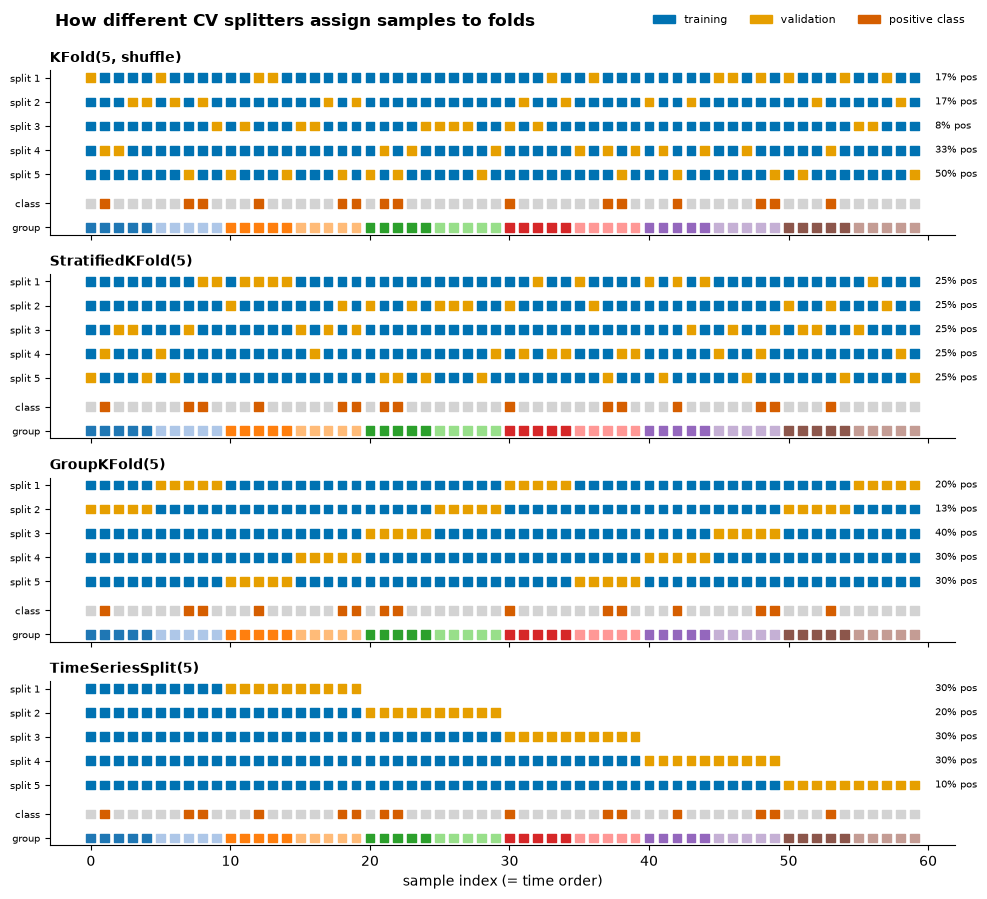

In [2]:
n_toy = 60
y_toy = np.r_[np.zeros(45, int), np.ones(15, int)]
rng.shuffle(y_toy)
groups_toy = np.repeat(np.arange(12), 5)
X_toy = np.arange(n_toy).reshape(-1, 1)

splitters = {
    "KFold(5, shuffle)": KFold(5, shuffle=True, random_state=RANDOM_STATE),
    "StratifiedKFold(5)": StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    "GroupKFold(5)": GroupKFold(5),
    "TimeSeriesSplit(5)": TimeSeriesSplit(5),
}

fig, axes = plt.subplots(len(splitters), 1, figsize=(10, 9), sharex=True)
for ax, (name, cv) in zip(axes, splitters.items()):
    split_iter = cv.split(X_toy, y_toy, groups_toy) if isinstance(cv, GroupKFold) else cv.split(X_toy, y_toy)
    for i, (tr, te) in enumerate(split_iter):
        row = np.full(n_toy, np.nan)
        row[tr], row[te] = 0, 1
        ax.scatter(np.arange(n_toy), np.full(n_toy, i), c=[PALETTE[0] if v == 0 else PALETTE[1]
                                                            if v == 1 else "white" for v in row],
                   marker="s", s=40)
        pos_share = y_toy[te].mean()
        ax.text(n_toy + 0.5, i, f"{pos_share:.0%} pos", va="center", fontsize=7)
    ax.scatter(np.arange(n_toy), np.full(n_toy, i + 1.2), c=[PALETTE[3] if v else "lightgray" for v in y_toy],
               marker="s", s=40)
    ax.scatter(np.arange(n_toy), np.full(n_toy, i + 2.2), c=[plt.cm.tab20(g) for g in groups_toy],
               marker="s", s=40)
    ax.set_yticks(list(range(i + 1)) + [i + 1.2, i + 2.2],
                  [f"split {k + 1}" for k in range(i + 1)] + ["class", "group"], fontsize=7)
    ax.set_title(name, loc="left", fontsize=10)
    ax.grid(False)
    ax.invert_yaxis()
axes[-1].set_xlabel("sample index (= time order)")
fig.legend(handles=[Patch(color=PALETTE[0], label="training"), Patch(color=PALETTE[1], label="validation"),
                    Patch(color=PALETTE[3], label="positive class")],
           loc="upper right", ncol=3, fontsize=8, bbox_to_anchor=(0.98, 1.0))
fig.suptitle("How different CV splitters assign samples to folds", fontweight="bold", x=0.3, y=0.99)
fig.tight_layout()
savefig("cv_splitters")
plt.show()

- **KFold** folds can have quite different class shares; **StratifiedKFold** keeps ~25 % positives everywhere.
- **GroupKFold** keeps each coloured group entirely in one validation fold.
- **TimeSeriesSplit** uses an expanding window: training data always precedes validation data, and the first
  samples are never validated on.

### Why groups matter: a leakage demo

Imagine 100 patients with 10 scans each. Each patient's scans look alike (a patient "fingerprint"), and the label
is a patient-level property that is **pure noise** — there is nothing to learn. A 1-nearest-neighbour model can
still "recognise" the patient, so ordinary k-fold, which puts scans of the same patient in train *and*
validation, reports a fantastic score.

In [3]:
n_pat, per_pat = 100, 10
fingerprint = rng.normal(size=(n_pat, 5))
X_grp = np.repeat(fingerprint, per_pat, axis=0) + 0.1 * rng.normal(size=(n_pat * per_pat, 5))
y_grp = np.repeat(rng.integers(0, 2, n_pat), per_pat)  # random label per patient: nothing to learn
g_grp = np.repeat(np.arange(n_pat), per_pat)
knn = KNeighborsClassifier(n_neighbors=1)
acc_kfold = cross_val_score(knn, X_grp, y_grp, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))
acc_group = cross_val_score(knn, X_grp, y_grp, cv=GroupKFold(5), groups=g_grp)
print(f"KFold      accuracy: {acc_kfold.mean():.3f}  <- leakage: same patient in train and validation")
print(f"GroupKFold accuracy: {acc_group.mean():.3f}  <- honest: labels are coin flips")

KFold      accuracy: 1.000  <- leakage: same patient in train and validation
GroupKFold accuracy: 0.587  <- honest: labels are coin flips


## 2 · How noisy is a CV estimate?

A CV score is itself a random variable: it depends on how the data happen to be shuffled into folds (and, more
fundamentally, on which data we collected). Let's repeat stratified $k$-fold CV with 40 different shuffles for
several $k$ on the breast-cancer data with a scaled logistic regression.

Throughout this chapter we make **malignant = 1 (positive class)** — the class we want to detect.

In [4]:
cancer = load_breast_cancer()
X_bc = cancer.data
y_bc = 1 - cancer.target  # sklearn codes malignant as 0; flip so malignant = 1
print(f"{len(y_bc)} tumours, {y_bc.mean():.1%} malignant")
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

cv_var = {}
for k in [2, 5, 10, 20]:
    means, folds = [], []
    for seed in range(40):
        s = cross_val_score(logreg, X_bc, y_bc, cv=StratifiedKFold(k, shuffle=True, random_state=seed),
                            n_jobs=-1)
        means.append(s.mean())
        folds.append(s)
    cv_var[k] = dict(means=np.array(means), folds=np.concatenate(folds))
summary = pd.DataFrame({k: {"mean of CV means": v["means"].mean(), "std of CV mean (over shuffles)": v["means"].std(),
                            "std of single-fold scores": v["folds"].std(), "min CV mean": v["means"].min(),
                            "max CV mean": v["means"].max()} for k, v in cv_var.items()}).T
summary.index.name = "k"
summary

569 tumours, 37.3% malignant


,mean of CV means,std of CV mean (over shuffles),std of single-fold scores,min CV mean,max CV mean
k,,,,,
2,0.9754,0.0042,0.0072,0.9666,0.9859
5,0.9782,0.0030,0.0125,0.9719,0.9842
10,0.9786,0.0025,0.0178,0.9736,0.9842
20,0.9791,0.0019,0.0263,0.9754,0.9826


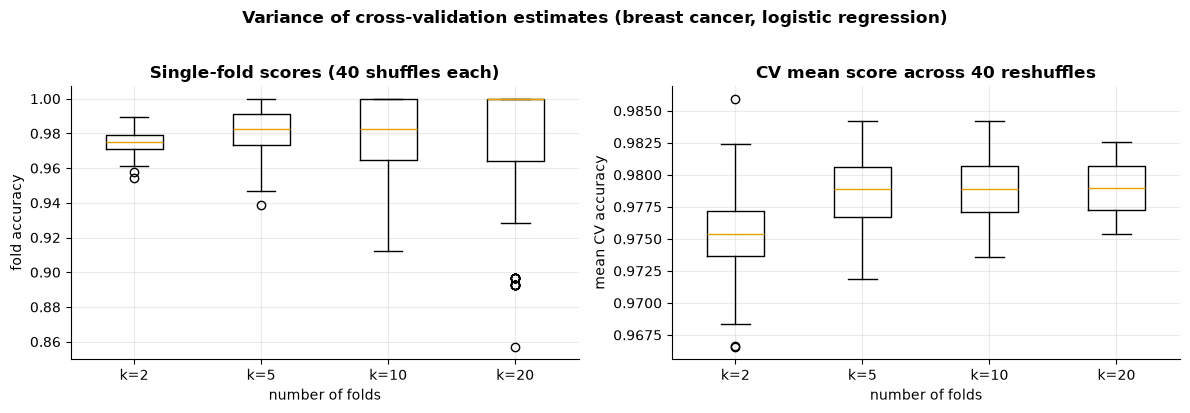

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([cv_var[k]["folds"] for k in cv_var], tick_labels=[f"k={k}" for k in cv_var])
axes[0].set(title="Single-fold scores (40 shuffles each)", xlabel="number of folds",
            ylabel="fold accuracy")
axes[1].boxplot([cv_var[k]["means"] for k in cv_var], tick_labels=[f"k={k}" for k in cv_var])
axes[1].set(title="CV mean score across 40 reshuffles", xlabel="number of folds",
            ylabel="mean CV accuracy")
fig.suptitle("Variance of cross-validation estimates (breast cancer, logistic regression)", fontweight="bold",
             y=1.02)
fig.tight_layout()
savefig("cv_variance")
plt.show()

Individual folds scatter widely (a fold of ~28 tumours at $k=20$ moves in steps of 3.6 %), and even the
*average* moves by several tenths of a percent just by reshuffling. Differences between models smaller than this
noise are not meaningful. Repeated CV (`RepeatedStratifiedKFold`) averages out the shuffle noise; it cannot remove
the noise from having only 569 samples.

### `cross_validate` with several metrics

`cross_validate` returns fit/score times and any number of metrics (and optionally training scores and the
fitted estimators):

In [6]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc", "neg_log_loss"]
cv10 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
models = {
    "LogisticRegression": logreg,
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "GaussianNB": GaussianNB(),
}
rows = {}
for name, model in models.items():
    res = cross_validate(model, X_bc, y_bc, cv=cv10, scoring=scoring, return_train_score=True, n_jobs=-1)
    rows[name] = {m: f"{res['test_' + m].mean():.3f} ± {res['test_' + m].std():.3f}" for m in scoring}
    rows[name]["train accuracy"] = f"{res['train_accuracy'].mean():.3f}"
    rows[name]["fit time (s)"] = f"{res['fit_time'].mean():.3f}"
pd.DataFrame(rows).T

,accuracy,precision,recall,f1,roc_auc,neg_log_loss,train accuracy,fit time (s)
LogisticRegression,0.976 ± 0.013,0.984 ± 0.014,0.951 ± 0.036,0.967 ± 0.018,0.995 ± 0.005,-0.079 ± 0.028,0.988,0.012
RandomForest,0.960 ± 0.020,0.958 ± 0.036,0.934 ± 0.049,0.945 ± 0.028,0.990 ± 0.009,-0.174 ± 0.132,1.000,0.723
GaussianNB,0.939 ± 0.017,0.945 ± 0.031,0.888 ± 0.049,0.915 ± 0.025,0.988 ± 0.006,-0.612 ± 0.300,0.943,0.003


## 3 · The confusion matrix and the metrics built on it

We hold out 25 % of the tumours and fit the logistic regression on the rest.

In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.25, stratify=y_bc,
                                          random_state=RANDOM_STATE)
logreg.fit(X_tr, y_tr)
proba_te = logreg.predict_proba(X_te)[:, 1]
pred_te = (proba_te >= 0.5).astype(int)

# From scratch: count the four cells
TP = int(np.sum((pred_te == 1) & (y_te == 1)))
FP = int(np.sum((pred_te == 1) & (y_te == 0)))
FN = int(np.sum((pred_te == 0) & (y_te == 1)))
TN = int(np.sum((pred_te == 0) & (y_te == 0)))
print(f"TP={TP}  FP={FP}  FN={FN}  TN={TN}")
print("sklearn confusion_matrix (rows = true, cols = predicted, order [0, 1]):")
print(confusion_matrix(y_te, pred_te))
assert np.array_equal(confusion_matrix(y_te, pred_te), [[TN, FP], [FN, TP]])

TP=49  FP=1  FN=4  TN=89
sklearn confusion_matrix (rows = true, cols = predicted, order [0, 1]):
[[89  1]
 [ 4 49]]


$$\text{precision} = \frac{TP}{TP+FP}\qquad \text{recall (sensitivity, TPR)} = \frac{TP}{TP+FN}\qquad
  \text{specificity (TNR)} = \frac{TN}{TN+FP}$$

$$F_1 = \frac{2\cdot\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}\qquad
  \text{accuracy} = \frac{TP+TN}{TP+FP+FN+TN}$$

*Precision*: of the tumours we flagged, how many were malignant? *Recall*: of the malignant tumours, how many
did we catch? *Specificity*: of the benign ones, how many did we correctly clear?

In [8]:
ours = {
    "accuracy": (TP + TN) / (TP + FP + FN + TN),
    "precision": TP / (TP + FP),
    "recall": TP / (TP + FN),
    "specificity": TN / (TN + FP),
}
ours["f1"] = 2 * ours["precision"] * ours["recall"] / (ours["precision"] + ours["recall"])
sk = {
    "accuracy": accuracy_score(y_te, pred_te),
    "precision": precision_score(y_te, pred_te),
    "recall": recall_score(y_te, pred_te),
    "specificity": recall_score(y_te, pred_te, pos_label=0),  # specificity = recall of the negative class
    "f1": f1_score(y_te, pred_te),
}
pd.DataFrame({"from scratch": ours, "sklearn": sk}).assign(match=lambda d: np.isclose(d.iloc[:, 0], d.iloc[:, 1]))

,from scratch,sklearn,match
accuracy,0.9650,0.9650,True
precision,0.9800,0.9800,True
recall,0.9245,0.9245,True
specificity,0.9889,0.9889,True
f1,0.9515,0.9515,True


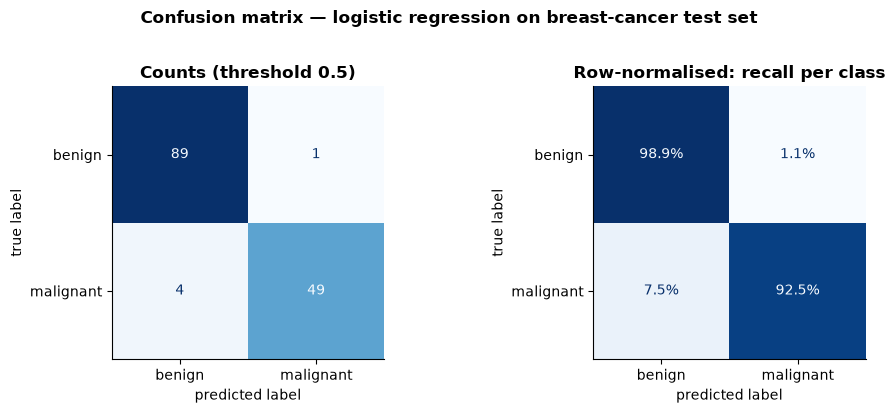

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_te, pred_te, display_labels=["benign", "malignant"], cmap="Blues",
                                        ax=axes[0], colorbar=False)
axes[0].set_title("Counts (threshold 0.5)")
ConfusionMatrixDisplay.from_predictions(y_te, pred_te, display_labels=["benign", "malignant"], cmap="Blues",
                                        normalize="true", values_format=".1%", ax=axes[1], colorbar=False)
axes[1].set_title("Row-normalised: recall per class")
for ax in axes:
    ax.grid(False)
    ax.set(xlabel="predicted label", ylabel="true label")
fig.suptitle("Confusion matrix — logistic regression on breast-cancer test set", fontweight="bold", y=1.02)
fig.tight_layout()
savefig("confusion_matrix")
plt.show()

## 4 · The accuracy paradox

On imbalanced data accuracy is dominated by the majority class. Let's build a fraud-like problem with **2 %**
positives (60 000 samples; `flip_y` label noise pushes the actual rate to ~2.5 %). A "model" that always predicts *negative* is ~97.5 % accurate and completely useless.

In [10]:
X_im, y_im = make_classification(n_samples=60000, n_features=20, n_informative=6, n_redundant=4,
                                 weights=[0.98], class_sep=0.8, flip_y=0.01, random_state=RANDOM_STATE)
X_im_tr, X_im_te, y_im_tr, y_im_te = train_test_split(X_im, y_im, test_size=0.3, stratify=y_im,
                                                      random_state=RANDOM_STATE)
print(f"positive rate: train {y_im_tr.mean():.2%}, test {y_im_te.mean():.2%}")

dummy = DummyClassifier(strategy="most_frequent").fit(X_im_tr, y_im_tr)
lr_im = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_im_tr, y_im_tr)
hgb_im = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(X_im_tr, y_im_tr)

rows = {}
for name, m in {"Always negative (dummy)": dummy, "Logistic regression": lr_im, "HistGradientBoosting": hgb_im}.items():
    p = m.predict(X_im_te)
    rows[name] = {"accuracy": accuracy_score(y_im_te, p),
                  "precision": precision_score(y_im_te, p, zero_division=0),
                  "recall": recall_score(y_im_te, p), "f1": f1_score(y_im_te, p)}
pd.DataFrame(rows).T

positive rate: train 2.46%, test 2.46%


,accuracy,precision,recall,f1
Always negative (dummy),0.9754,0.0000,0.0000,0.0000
Logistic regression,0.9766,0.8182,0.0611,0.1137
HistGradientBoosting,0.9860,0.9060,0.4796,0.6272


All three have ~97–98 % accuracy, but recall tells the real story. The dummy catches **no** positives, and even the
real models at the default 0.5 threshold miss a large share of them.

## 5 · Threshold moving

`predict` thresholds the predicted probability at 0.5. That threshold is a *business decision*, not part of
the model. Lowering it trades precision for recall.

In [11]:
proba_lr_im = lr_im.predict_proba(X_im_te)[:, 1]
proba_hgb_im = hgb_im.predict_proba(X_im_te)[:, 1]
thresholds = np.linspace(0.01, 0.95, 95)
curves = {"precision": [], "recall": [], "f1": []}
for t in thresholds:
    p = (proba_hgb_im >= t).astype(int)
    curves["precision"].append(precision_score(y_im_te, p, zero_division=0))
    curves["recall"].append(recall_score(y_im_te, p))
    curves["f1"].append(f1_score(y_im_te, p))
best_f1_t = thresholds[np.argmax(curves["f1"])]
print(f"F1-optimal threshold on the test set: {best_f1_t:.2f} (F1 = {max(curves['f1']):.3f}); "
      f"F1 at 0.5 = {curves['f1'][np.argmin(abs(thresholds - 0.5))]:.3f}")

F1-optimal threshold on the test set: 0.20 (F1 = 0.673); F1 at 0.5 = 0.627


> **Careful:** we just picked the threshold on the *test* set — fine for illustration, but in practice choose it
> on validation data or with CV (below, `TunedThresholdClassifierCV`), otherwise the test score is optimistic.

### Choosing a threshold by cost

Suppose a missed positive (FN, e.g. undetected fraud) costs **25** units and a false alarm (FP, a manual review)
costs **1**. The expected cost per case at threshold $t$ is

$$\text{cost}(t) = \frac{1}{n}\big(c_{FP}\,FP(t) + c_{FN}\,FN(t)\big).$$

For a *perfectly calibrated* probability $p$, flagging is worth it when $p\,c_{FN} > (1-p)\,c_{FP}$, i.e. above
$t^* = c_{FP}/(c_{FP}+c_{FN}) = 1/26 \approx 0.038$. With real (imperfectly calibrated) models we let
cross-validation find the threshold: `TunedThresholdClassifierCV` does exactly that, using only training data.

In [12]:
C_FP, C_FN = 1, 25


def cost_per_case(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return (C_FP * cm[0, 1] + C_FN * cm[1, 0]) / len(y_true)


cost_scorer = make_scorer(cost_per_case, greater_is_better=False)
tuned = TunedThresholdClassifierCV(HistGradientBoostingClassifier(random_state=RANDOM_STATE), scoring=cost_scorer,
                                   cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                                   n_jobs=-1).fit(X_im_tr, y_im_tr)
cost_curve = [cost_per_case(y_im_te, (proba_hgb_im >= t).astype(int)) for t in thresholds]
t_theory = C_FP / (C_FP + C_FN)
print(f"CV-tuned threshold: {tuned.best_threshold_:.3f}   (Bayes threshold for calibrated probs: {t_theory:.3f})")
print(f"test cost per case  @0.5: {cost_per_case(y_im_te, hgb_im.predict(X_im_te)):.4f}")
print(f"test cost per case  @tuned: {cost_per_case(y_im_te, tuned.predict(X_im_te)):.4f}")
print(f"test cost per case  flag nobody: {cost_per_case(y_im_te, np.zeros_like(y_im_te)):.4f}")

CV-tuned threshold: 0.041   (Bayes threshold for calibrated probs: 0.038)


test cost per case  @0.5: 0.3207


test cost per case  @tuned: 0.2196
test cost per case  flag nobody: 0.6139


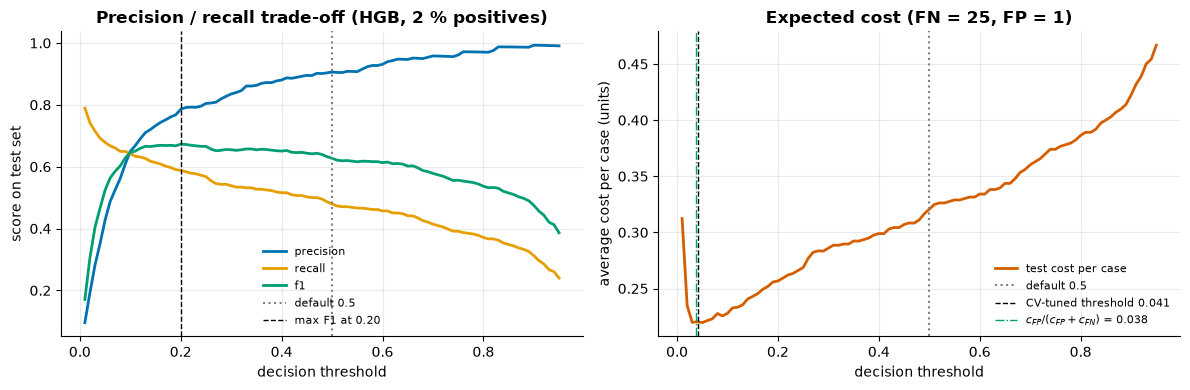

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for key, c in zip(curves, PALETTE):
    axes[0].plot(thresholds, curves[key], label=key, color=c, lw=2)
axes[0].axvline(0.5, color="gray", ls=":", label="default 0.5")
axes[0].axvline(best_f1_t, color="k", ls="--", lw=1, label=f"max F1 at {best_f1_t:.2f}")
axes[0].set(title="Precision / recall trade-off (HGB, 2 % positives)", xlabel="decision threshold",
            ylabel="score on test set")
axes[0].legend(fontsize=8)
axes[1].plot(thresholds, cost_curve, color=PALETTE[3], lw=2, label="test cost per case")
axes[1].axvline(0.5, color="gray", ls=":", label="default 0.5")
axes[1].axvline(tuned.best_threshold_, color="k", ls="--", lw=1,
                label=f"CV-tuned threshold {tuned.best_threshold_:.3f}")
axes[1].axvline(t_theory, color=PALETTE[2], ls="-.", lw=1, label=f"$c_{{FP}}/(c_{{FP}}+c_{{FN}})$ = {t_theory:.3f}")
axes[1].set(title="Expected cost (FN = 25, FP = 1)", xlabel="decision threshold",
            ylabel="average cost per case (units)")
axes[1].legend(fontsize=8)
fig.tight_layout()
savefig("threshold_and_cost")
plt.show()

## 6 · ROC curve from scratch

The **ROC curve** plots the true-positive rate (recall) against the false-positive rate ($1-$specificity) for
**every** threshold. We sweep the thresholds explicitly — each distinct predicted score, from high to low — and
compare with `roc_curve`. Back to the breast-cancer logistic regression.

In [14]:
def roc_from_scratch(y_true, scores):
    """Sweep every distinct score as a threshold (high -> low) and return FPR, TPR, thresholds."""
    y_true = np.asarray(y_true)
    P, N = y_true.sum(), (1 - y_true).sum()
    thr = np.r_[np.inf, np.unique(scores)[::-1]]  # inf: nobody flagged -> (0, 0)
    tpr = np.array([np.sum((scores >= t) & (y_true == 1)) / P for t in thr])
    fpr = np.array([np.sum((scores >= t) & (y_true == 0)) / N for t in thr])
    return fpr, tpr, thr


def auc_trapezoid(x, y):
    return float(np.sum(np.diff(x) * (y[1:] + y[:-1]) / 2))


fpr_s, tpr_s, thr_s = roc_from_scratch(y_te, proba_te)
fpr_k, tpr_k, thr_k = roc_curve(y_te, proba_te, drop_intermediate=False)
print("same number of points:", len(fpr_s) == len(fpr_k))
print("FPR/TPR identical    :", np.allclose(fpr_s, fpr_k) and np.allclose(tpr_s, tpr_k))
print(f"AUC scratch (trapezoid) = {auc_trapezoid(fpr_s, tpr_s):.6f}")
print(f"roc_auc_score           = {roc_auc_score(y_te, proba_te):.6f}")

same number of points: True
FPR/TPR identical    : True
AUC scratch (trapezoid) = 0.996226
roc_auc_score           = 0.996226


### AUC as a probability

The area under the ROC curve equals the probability that a randomly chosen **positive** gets a higher score than
a randomly chosen **negative** (ties count ½) — the Mann–Whitney $U$ statistic:

$$\text{AUC} = P\big(s(X^+) > s(X^-)\big) = \frac{1}{PN}\sum_{i:y_i=1}\sum_{j:y_j=0}\Big[\mathbb 1(s_i>s_j) + \tfrac12\mathbb 1(s_i=s_j)\Big].$$

So AUC is a **ranking** metric: it ignores the threshold and the calibration of the scores.

In [15]:
s_pos, s_neg = proba_te[y_te == 1], proba_te[y_te == 0]
pairwise = (s_pos[:, None] > s_neg[None, :]).mean() + 0.5 * (s_pos[:, None] == s_neg[None, :]).mean()
print(f"P(score_pos > score_neg) over all {len(s_pos) * len(s_neg)} pairs = {pairwise:.6f}")
u_stat = stats.mannwhitneyu(s_pos, s_neg).statistic
print(f"Mann-Whitney U / (P*N)                    = {u_stat / (len(s_pos) * len(s_neg)):.6f}")

P(score_pos > score_neg) over all 4770 pairs = 0.996226
Mann-Whitney U / (P*N)                    = 0.996226


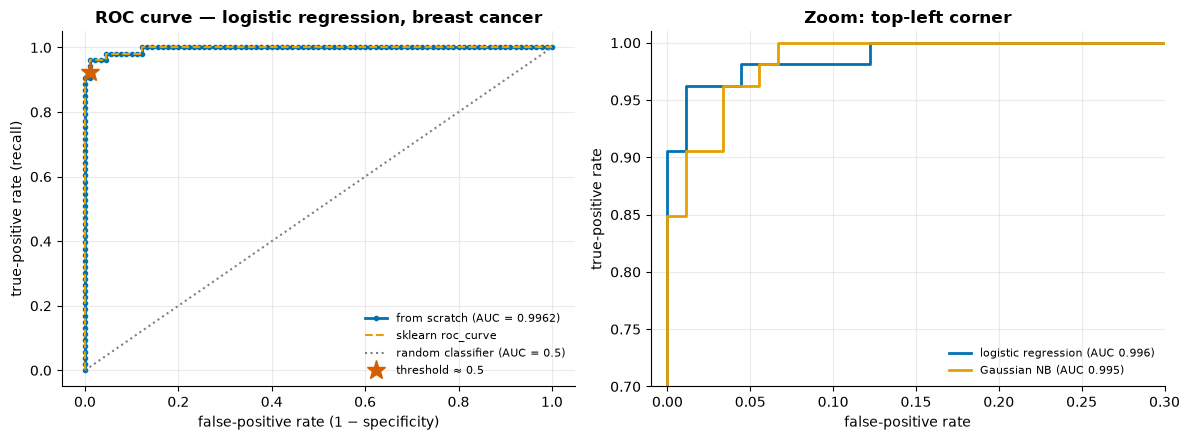

In [16]:
nb_te = GaussianNB().fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(fpr_s, tpr_s, "o-", ms=3, lw=2, label=f"from scratch (AUC = {auc_trapezoid(fpr_s, tpr_s):.4f})")
ax.plot(fpr_k, tpr_k, "--", color=PALETTE[1], lw=1.5, label="sklearn roc_curve")
ax.plot([0, 1], [0, 1], ":", color="gray", label="random classifier (AUC = 0.5)")
i05 = np.argmin(np.abs(thr_s - 0.5))
ax.plot(fpr_s[i05], tpr_s[i05], "*", color=PALETTE[3], ms=14, label="threshold ≈ 0.5")
ax.set(title="ROC curve — logistic regression, breast cancer", xlabel="false-positive rate (1 − specificity)",
       ylabel="true-positive rate (recall)")
ax.legend(fontsize=8, loc="lower right")
ax = axes[1]
ax.plot(fpr_s, tpr_s, lw=2, label=f"logistic regression (AUC {roc_auc_score(y_te, proba_te):.3f})")
f_nb, t_nb, _ = roc_curve(y_te, nb_te)
ax.plot(f_nb, t_nb, lw=2, label=f"Gaussian NB (AUC {roc_auc_score(y_te, nb_te):.3f})")
ax.plot([0, 1], [0, 1], ":", color="gray")
ax.set(title="Zoom: top-left corner", xlabel="false-positive rate", ylabel="true-positive rate",
       xlim=(-0.01, 0.3), ylim=(0.7, 1.01))
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
savefig("roc_from_scratch")
plt.show()

## 7 · Precision–recall curves under heavy imbalance

The FPR divides by the number of **negatives**. When negatives vastly outnumber positives, even thousands of
false alarms are a small FPR, so the ROC curve (and ROC AUC) can look excellent while most flagged cases are false
alarms. The **precision–recall curve** uses precision instead, which is directly hurt by false positives.
Its summary, **average precision** (AP), is

$$\text{AP} = \sum_n (R_n - R_{n-1})\,P_n,$$

and a random classifier has AP ≈ prevalence (not 0.5).

To isolate the effect of imbalance, we take **one** fitted model (HGB from above) and evaluate it on versions of
the test set with the same 80 positives but 320 to 15 920 negatives: 20 %, 5 %, 1 % and 0.5 % prevalence. The model and its scores do
not change — only the class ratio does.

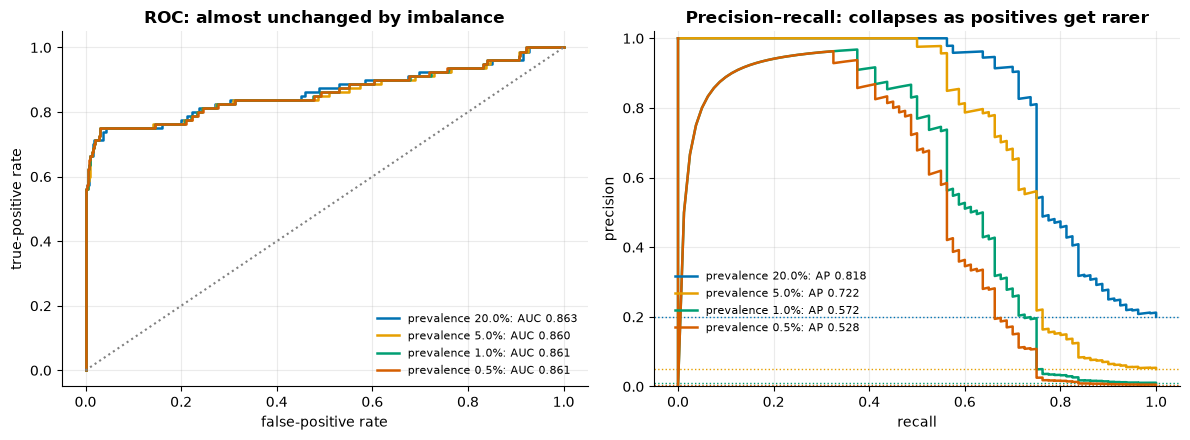

,prevalence,positives,negatives,roc_auc,average_precision
0,20.0%,80,320,0.8633,0.8179
1,5.0%,80,1520,0.8601,0.7218
2,1.0%,80,7920,0.8615,0.5718
3,0.5%,80,15920,0.8615,0.5278


In [17]:
pos_idx, neg_idx = np.flatnonzero(y_im_te == 1), np.flatnonzero(y_im_te == 0)
N_POS = 80  # keep the same 80 positives in every version, vary the number of negatives
pos_keep = rng.choice(pos_idx, size=N_POS, replace=False)
prevalence_sets = {}
for prev in [0.2, 0.05, 0.01, 0.005]:
    n_neg = int(round(N_POS * (1 - prev) / prev))
    prevalence_sets[prev] = np.r_[pos_keep, rng.choice(neg_idx, size=n_neg, replace=False)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rows = []
for (prev, idx), c in zip(prevalence_sets.items(), PALETTE):
    yt, st = y_im_te[idx], proba_hgb_im[idx]
    fpr, tpr, _ = roc_curve(yt, st)
    prec, rec, _ = precision_recall_curve(yt, st)
    auc, ap = roc_auc_score(yt, st), average_precision_score(yt, st)
    rows.append(dict(prevalence=f"{yt.mean():.1%}", positives=int(yt.sum()), negatives=int((1 - yt).sum()),
                     roc_auc=auc, average_precision=ap))
    axes[0].plot(fpr, tpr, color=c, lw=1.8, label=f"prevalence {yt.mean():.1%}: AUC {auc:.3f}")
    axes[1].plot(rec, prec, color=c, lw=1.8, label=f"prevalence {yt.mean():.1%}: AP {ap:.3f}")
    axes[1].axhline(yt.mean(), color=c, ls=":", lw=1)
axes[0].plot([0, 1], [0, 1], ":", color="gray")
axes[0].set(title="ROC: almost unchanged by imbalance", xlabel="false-positive rate", ylabel="true-positive rate")
axes[1].set(title="Precision–recall: collapses as positives get rarer", xlabel="recall", ylabel="precision",
            ylim=(0, 1.02))
axes[0].legend(fontsize=8, loc="lower right")
axes[1].legend(fontsize=8, loc="lower left", bbox_to_anchor=(0.02, 0.12))
fig.tight_layout()
savefig("roc_vs_pr_imbalance")
plt.show()
pd.DataFrame(rows)

Same model, same scores: ROC AUC barely moves, but average precision drops dramatically, because at 0.5 %
prevalence each true positive is buried among many more negatives with similar scores. **When positives are rare
and you care about the flagged cases, report the PR curve / AP** (dotted lines = the no-skill baseline, equal to
the prevalence).

## 8 · Calibration

A classifier is **calibrated** if, among all cases where it says "70 %", about 70 % are positive:
$P(Y=1 \mid \hat p = p) = p$. Ranking metrics (AUC) do not care, but calibration matters whenever the probability
itself is used — expected-cost decisions, risk scores, combining models.

A **reliability diagram** bins the predictions and plots the observed positive fraction per bin against the mean
predicted probability. The **Brier score** is the MSE of probabilities, $\frac1n\sum(\hat p_i - y_i)^2$
(lower is better), and mixes calibration and discrimination.

Following scikit-learn's classic example, we train four models on 2 000 samples of a synthetic problem with
redundant features and evaluate on 18 000. `SVC` has no `predict_proba` by default, so we min–max scale its
`decision_function` into $[0, 1]$ as a naive "probability".

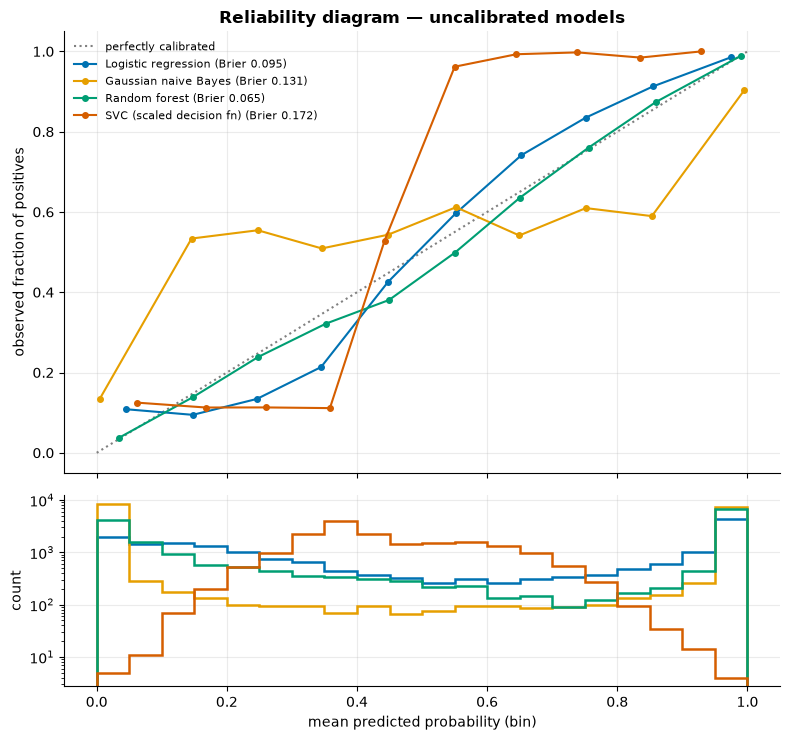

,brier,log_loss,roc_auc
model,,,
Logistic regression,0.0948,0.3321,0.9273
Gaussian naive Bayes,0.1315,0.8483,0.9281
Random forest,0.0649,0.2689,0.9654
SVC (scaled decision fn),0.1715,0.5298,0.9265


In [18]:
X_cal, y_cal = make_classification(n_samples=20000, n_features=20, n_informative=2, n_redundant=10,
                                   random_state=RANDOM_STATE)
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(X_cal, y_cal, train_size=2000, random_state=RANDOM_STATE)


class ScaledSVC(SVC):
    """SVC whose predict_proba is the min-max scaled decision function (NOT a real probability)."""

    def predict_proba(self, X):
        d = self.decision_function(X)
        p = (d - d.min()) / (d.max() - d.min())
        return np.column_stack([1 - p, p])


cal_models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Gaussian naive Bayes": GaussianNB(),
    "Random forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "SVC (scaled decision fn)": make_pipeline(StandardScaler(), ScaledSVC(kernel="linear", C=1.0)),
}


def reliability_plot(models, title, fname):
    fig, (ax, axh) = plt.subplots(2, 1, figsize=(8, 7.5), gridspec_kw={"height_ratios": [3, 1.3]}, sharex=True)
    ax.plot([0, 1], [0, 1], ":", color="gray", label="perfectly calibrated")
    rows = []
    for (name, m), c in zip(models.items(), PALETTE):
        prob = m.predict_proba(X_c_te)[:, 1]
        frac_pos, mean_pred = calibration_curve(y_c_te, prob, n_bins=10)
        bs = brier_score_loss(y_c_te, prob)
        ax.plot(mean_pred, frac_pos, "o-", color=c, ms=4, label=f"{name} (Brier {bs:.3f})")
        axh.hist(prob, bins=20, range=(0, 1), histtype="step", lw=1.8, color=c)
        rows.append(dict(model=name, brier=bs, log_loss=log_loss(y_c_te, np.clip(prob, 1e-15, 1 - 1e-15)),
                         roc_auc=roc_auc_score(y_c_te, prob)))
    ax.set(title=title, ylabel="observed fraction of positives")
    ax.legend(fontsize=8, loc="upper left")
    axh.set(xlabel="mean predicted probability (bin)", ylabel="count")
    axh.set_yscale("log")
    fig.tight_layout()
    savefig(fname)
    plt.show()
    return pd.DataFrame(rows).set_index("model")


for m in cal_models.values():
    m.fit(X_c_tr, y_c_tr)
reliability_plot(cal_models, "Reliability diagram — uncalibrated models", "calibration_uncalibrated")

Typical patterns (see Niculescu-Mizil & Caruana, 2005):

- **Logistic regression** is fairly close to the diagonal (it directly optimises log loss); here it is mildly
  *under*-confident at the low end because the model is slightly misspecified.
- **Gaussian NB** is badly **over-confident**: the histogram shows almost all predictions at 0 or 1, and the few
  mid-range ones are close to coin flips. The 10 redundant features violate its independence assumption, so the
  same evidence is counted many times.
- **Random forest** is nearly on the diagonal in this setup, with the best Brier score. Forests are often slightly
  under-confident near 0 and 1, because averaging trees rarely gives a unanimous vote.
- **SVC**'s rescaled margin is a steep S-curve (a step): a distance to the hyperplane is not a probability.

### Fixing calibration: `CalibratedClassifierCV`

`CalibratedClassifierCV` learns a monotone map from scores to probabilities on held-out folds:

- `method="sigmoid"` (Platt scaling): fit $p = \sigma(a\,s + b)$ — 2 parameters, good for S-shaped distortions
  and small data.
- `method="isotonic"`: fit a non-parametric non-decreasing step function — more flexible, needs more data
  (≳ 1 000 calibration samples) or it overfits.

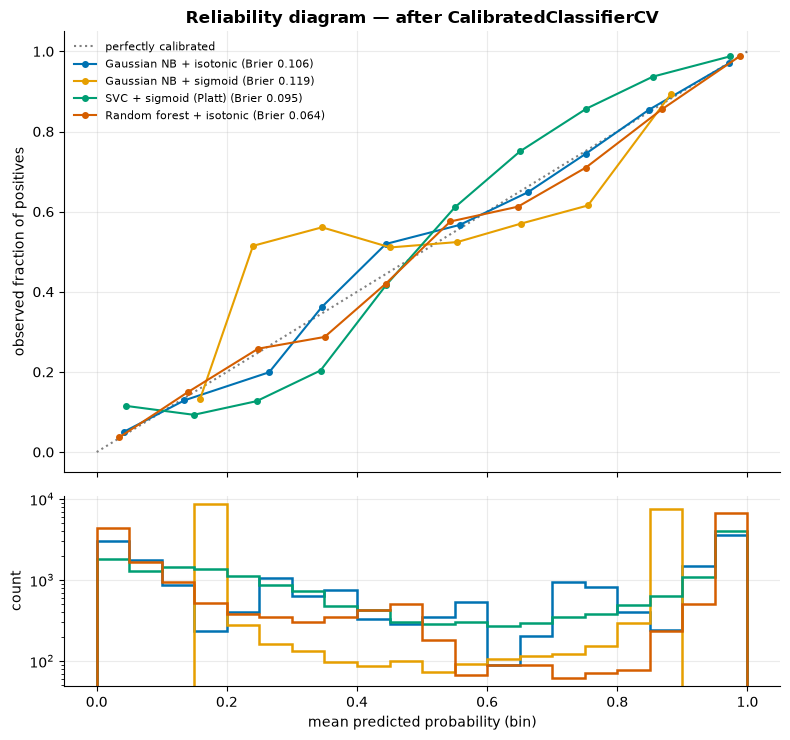

In [19]:
calibrated = {
    "Gaussian NB + isotonic": CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5),
    "Gaussian NB + sigmoid": CalibratedClassifierCV(GaussianNB(), method="sigmoid", cv=5),
    "SVC + sigmoid (Platt)": CalibratedClassifierCV(make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0)),
                                                    method="sigmoid", cv=5),
    "Random forest + isotonic": CalibratedClassifierCV(
        RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), method="isotonic", cv=5),
}
for m in calibrated.values():
    m.fit(X_c_tr, y_c_tr)
cal_table = reliability_plot(calibrated, "Reliability diagram — after CalibratedClassifierCV", "calibration_calibrated")

In [20]:
uncal_rows = []
for name, m in cal_models.items():
    prob = m.predict_proba(X_c_te)[:, 1]
    uncal_rows.append(dict(model=name, brier=brier_score_loss(y_c_te, prob),
                           log_loss=log_loss(y_c_te, np.clip(prob, 1e-15, 1 - 1e-15)),
                           roc_auc=roc_auc_score(y_c_te, prob)))
pd.concat({"uncalibrated": pd.DataFrame(uncal_rows).set_index("model"), "calibrated": cal_table})

brier  log_loss  roc_auc
             model                                              
uncalibrated Logistic regression       0.0948    0.3321   0.9273
             Gaussian naive Bayes      0.1315    0.8483   0.9281
             Random forest             0.0649    0.2689   0.9654
             SVC (scaled decision fn)  0.1715    0.5298   0.9265
calibrated   Gaussian NB + isotonic    0.1064    0.3618   0.9279
             Gaussian NB + sigmoid     0.1189    0.3950   0.9284
             SVC + sigmoid (Platt)     0.0951    0.3328   0.9266
             Random forest + isotonic  0.0645    0.2208   0.9658

Calibration lowers the Brier score and log loss substantially for NB and SVC while ROC AUC is almost unchanged —
a monotone map cannot change the ranking (small AUC changes come from averaging the 5 CV-fold models).
Platt scaling fixes the SVC's S-curve almost perfectly. For NB, sigmoid helps less than isotonic: NB's
probabilities are saturated at 0 and 1 and a sigmoid cannot "un-squash" them, while isotonic regression
can remap them freely. The random forest was already well calibrated, so the gain is small (log loss improves the most).

## 9 · Regression metrics and residual plots

| Metric | Formula | Units | Notes |
|---|---|---|---|
| MAE | $\frac1n\sum\lvert y-\hat y\rvert$ | target | robust to outliers; median-optimal |
| RMSE | $\sqrt{\frac1n\sum(y-\hat y)^2}$ | target | penalises large errors; mean-optimal |
| $R^2$ | $1-\frac{\sum(y-\hat y)^2}{\sum(y-\bar y)^2}$ | none | share of variance explained; can be < 0 |
| MAPE | $\frac1n\sum\frac{\lvert y-\hat y\rvert}{\lvert y\rvert}$ | % | explodes near $y=0$; asymmetric |
| Median AE | $\text{median}\lvert y-\hat y\rvert$ | target | very robust |

In [21]:
diab = load_diabetes()
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(diab.data, diab.target, test_size=0.25, random_state=RANDOM_STATE)
reg_models = {
    "RidgeCV": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 13))),
    "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
}
reg_rows, reg_preds = {}, {}
for name, m in reg_models.items():
    pred = m.fit(Xd_tr, yd_tr).predict(Xd_te)
    reg_preds[name] = pred
    reg_rows[name] = {"MAE": mean_absolute_error(yd_te, pred), "RMSE": mean_squared_error(yd_te, pred) ** 0.5,
                      "R2": r2_score(yd_te, pred), "MAPE": mean_absolute_percentage_error(yd_te, pred),
                      "MedianAE": median_absolute_error(yd_te, pred)}
reg_rows["Predict the mean"] = {"MAE": mean_absolute_error(yd_te, np.full_like(yd_te, yd_tr.mean())),
                                "RMSE": mean_squared_error(yd_te, np.full_like(yd_te, yd_tr.mean())) ** 0.5,
                                "R2": r2_score(yd_te, np.full_like(yd_te, yd_tr.mean())),
                                "MAPE": mean_absolute_percentage_error(yd_te, np.full_like(yd_te, yd_tr.mean())),
                                "MedianAE": median_absolute_error(yd_te, np.full_like(yd_te, yd_tr.mean()))}
pd.DataFrame(reg_rows).T

,MAE,RMSE,R2,MAPE,MedianAE
RidgeCV,41.5073,53.3182,0.4859,0.3721,35.4929
RandomForest,41.8445,52.9048,0.4938,0.3848,35.9491
Predict the mean,65.5274,74.8812,-0.0140,0.6431,64.3444


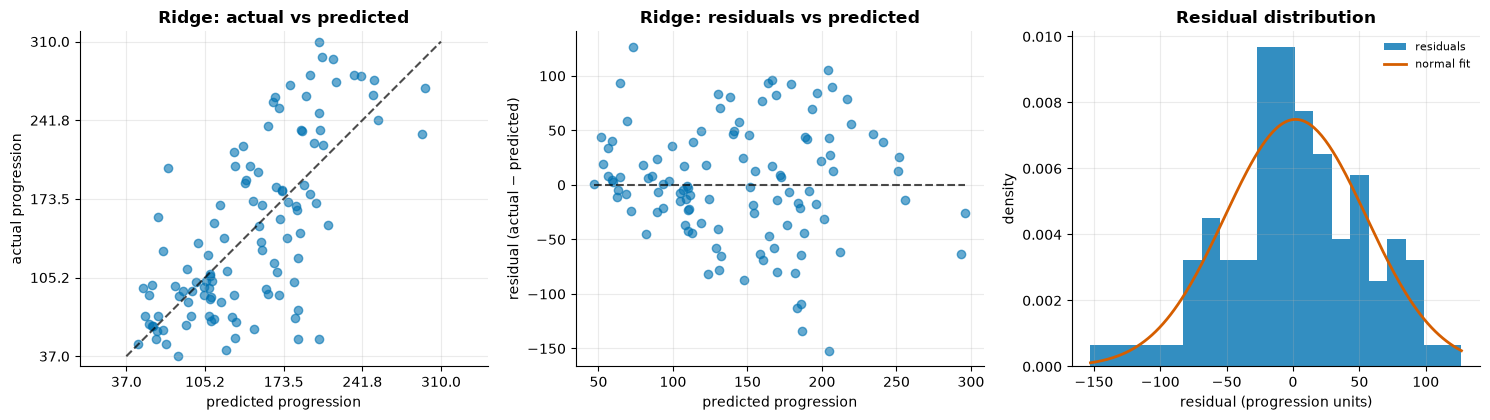

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
pred = reg_preds["RidgeCV"]
PredictionErrorDisplay.from_predictions(yd_te, pred, kind="actual_vs_predicted", ax=axes[0],
                                        scatter_kwargs={"alpha": 0.6, "color": PALETTE[0]})
axes[0].set(title="Ridge: actual vs predicted", xlabel="predicted progression", ylabel="actual progression")
PredictionErrorDisplay.from_predictions(yd_te, pred, kind="residual_vs_predicted", ax=axes[1],
                                        scatter_kwargs={"alpha": 0.6, "color": PALETTE[0]})
axes[1].set(title="Ridge: residuals vs predicted", xlabel="predicted progression",
            ylabel="residual (actual − predicted)")
resid = yd_te - pred
axes[2].hist(resid, bins=20, color=PALETTE[0], alpha=0.8, density=True, label="residuals")
xs = np.linspace(resid.min(), resid.max(), 200)
axes[2].plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std()), color=PALETTE[3], lw=2, label="normal fit")
axes[2].set(title="Residual distribution", xlabel="residual (progression units)", ylabel="density")
axes[2].legend(fontsize=8)
fig.tight_layout()
savefig("regression_residuals")
plt.show()

What to look for: points hugging the diagonal (left); residuals centred on zero with **no pattern** and constant
spread (middle) — a funnel means heteroscedasticity, a curve means a missing non-linearity; roughly symmetric
residuals (right). Here the fan widens slightly for large predictions, suggesting a log-transformed target could
help (see chapter 05).

## 10 · Is model A really better than model B?

Suppose logistic regression and a random forest have close CV accuracies. Is the difference real? Because both
models are evaluated on **the same folds**, compare the **paired** per-fold differences $d_j = s_j^A - s_j^B$
rather than two independent means — fold difficulty cancels out.

A naive paired $t$-test on $J$ CV differences is **over-confident**: training sets overlap, so the $d_j$ are
correlated. Nadeau & Bengio's **corrected resampled $t$-test** inflates the variance:

$$t = \frac{\bar d}{\sqrt{\left(\frac1J + \frac{n_\text{test}}{n_\text{train}}\right)\hat\sigma_d^2}},\qquad
  \text{df} = J-1.$$

In [23]:
cv_rep = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=RANDOM_STATE)
acc_lr = cross_val_score(logreg, X_bc, y_bc, cv=cv_rep, n_jobs=-1)
acc_rf = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), X_bc, y_bc,
                         cv=cv_rep, n_jobs=-1)
d = acc_lr - acc_rf
J = len(d)
n_test = len(y_bc) / 10
n_train = len(y_bc) - n_test


def t_test(d, correction):
    var = d.var(ddof=1) * (1 / len(d) + correction)
    t = d.mean() / np.sqrt(var)
    return t, 2 * stats.t.sf(abs(t), df=len(d) - 1)


t_naive, p_naive = t_test(d, 0.0)
t_corr, p_corr = t_test(d, n_test / n_train)
print(f"LogReg accuracy {acc_lr.mean():.4f} ± {acc_lr.std():.4f};  RF accuracy {acc_rf.mean():.4f} ± {acc_rf.std():.4f}")
print(f"mean paired difference = {d.mean():+.4f}; LogReg wins {np.mean(d > 0):.0%}, ties {np.mean(d == 0):.0%} of {J} folds")
print(f"naive paired t-test     : t = {t_naive:.2f}, p = {p_naive:.2g}")
print(f"corrected (Nadeau-Bengio): t = {t_corr:.2f}, p = {p_corr:.2g}")
print(f"correlation of per-fold accuracies: {np.corrcoef(acc_lr, acc_rf)[0, 1]:.2f}")
print(f"std of differences {d.std(ddof=1):.4f} vs sqrt(var_lr + var_rf) = "
      f"{np.sqrt(acc_lr.var(ddof=1) + acc_rf.var(ddof=1)):.4f} (what unpaired comparison would use)")

LogReg accuracy 0.9781 ± 0.0201;  RF accuracy 0.9606 ± 0.0254
mean paired difference = +0.0174; LogReg wins 60%, ties 23% of 100 folds
naive paired t-test     : t = 5.86, p = 6e-08
corrected (Nadeau-Bengio): t = 1.68, p = 0.095
correlation of per-fold accuracies: 0.17
std of differences 0.0297 vs sqrt(var_lr + var_rf) = 0.0325 (what unpaired comparison would use)


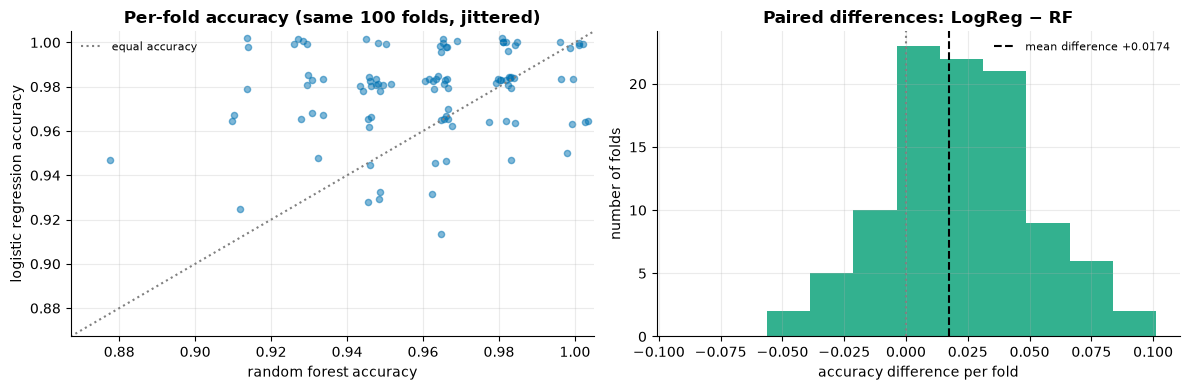

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
jit = rng.normal(0, 0.002, size=(2, J))  # jitter: fold accuracies are multiples of ~1/57
axes[0].scatter(acc_rf + jit[0], acc_lr + jit[1], alpha=0.5, s=20)
lims = [min(acc_lr.min(), acc_rf.min()) - 0.01, 1.005]
axes[0].plot(lims, lims, ":", color="gray", label="equal accuracy")
axes[0].set(title="Per-fold accuracy (same 100 folds, jittered)", xlabel="random forest accuracy",
            ylabel="logistic regression accuracy", xlim=lims, ylim=lims)
axes[0].legend(fontsize=8)
axes[1].hist(d, bins=np.arange(-0.1, 0.1, 0.0175) + 0.00875, color=PALETTE[2], alpha=0.8)
axes[1].axvline(0, color="gray", ls=":")
axes[1].axvline(d.mean(), color="k", ls="--", label=f"mean difference {d.mean():+.4f}")
axes[1].set(title="Paired differences: LogReg − RF", xlabel="accuracy difference per fold",
            ylabel="number of folds")
axes[1].legend(fontsize=8)
fig.tight_layout()
savefig("paired_differences")
plt.show()

Both tests agree on the direction, but the naive test declares a highly "significant" win (p ≈ 6·10⁻⁸) while
the corrected test says the evidence is weak (p ≈ 0.1): with 569 samples we cannot confidently claim that
logistic regression beats the forest on new data from this population. Pairing helps when fold difficulty is
shared by both models: a positive correlation of per-fold scores makes the differences less variable than the
scores themselves. Here the correlation is weak (0.17), so the gain is modest (std of differences 0.030 vs 0.033
for an unpaired comparison); on harder, noisier problems it is often much larger.

## Key takeaways

- Match the CV splitter to the data: **stratify** classification, **group** repeated measurements,
  respect **time** order. A wrong splitter silently leaks information (the group demo scored far above chance on
  pure noise).
- A CV score has variance: report mean ± std, use repeated CV on small data, and don't over-interpret small
  differences.
- Accuracy is misleading on imbalanced data. Look at the confusion matrix, precision, recall, specificity, F1 —
  and pick the **threshold** from costs, on validation data (`TunedThresholdClassifierCV`).
- ROC AUC = P(positive ranked above negative); it is threshold- and prevalence-independent. Under heavy imbalance
  prefer the **precision–recall curve / average precision**.
- Probabilities can be well-ranked yet badly **calibrated**; check reliability diagrams and the Brier score, and
  fix with `CalibratedClassifierCV` (sigmoid for small data, isotonic for large).
- For regression, report an error in target units (MAE/RMSE) plus $R^2$, and always inspect residual plots.
- Compare models on the **same folds** using paired differences, with a corrected test.

## Exercises

1. **Stratification matters more for small data.** Repeat the KFold vs StratifiedKFold comparison with 10 folds on
   the imbalanced dataset subsampled to 500 rows and plot the per-fold positive rate. *Hint:* some KFold folds may
   contain zero positives — what happens to recall then?
2. **PR curve from scratch.** Extend `roc_from_scratch` to also return precision, and verify against
   `precision_recall_curve`; compute AP with the step-sum formula. *Hint:* sklearn's curve ends with
   precision = 1, recall = 0.
3. **Cost-sensitive training.** Instead of moving the threshold, fit `LogisticRegression(class_weight={0: 1, 1: 25})`
   on the imbalanced data. How do its test cost and its calibration compare with the tuned threshold?
   *Hint:* class weights distort the probabilities — plot a reliability diagram.
4. **Isotonic overfitting.** Retrain the calibration experiment with only 200 training samples. Compare sigmoid vs
   isotonic Brier scores. *Hint:* use `train_size=200` in the split.
5. **Time-series leakage.** Create a random-walk series, predict tomorrow from the last 5 days with a random forest,
   and compare `KFold(shuffle=True)` to `TimeSeriesSplit`. *Hint:* `np.cumsum(rng.normal(size=1000))`.